In [1]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (COPPER_AVERAGE_REGIONS_TO_IMAGE, 
                                          copper_regions, 
                                          REGION_TO_CLASS_DICT)

In [2]:
# COPPER
copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 2012)

copper.data_grouped_regions(regions_grouping = copper_regions) #list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()
copper.sum_IMAGE_drivers_regions(COPPER_AVERAGE_REGIONS_TO_IMAGE)
copper.match_MAT_data_to_regions_year(match_external_regions=True)
copper.calculate_historic_other_fraction()

In [3]:
# test if there are negative values in other fraction 
copper.historic_other_fraction_consumption

,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,-26084.331474,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,-173828.206066,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,-4421.999531,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,-52525.497531,7.085295e+05,309475.069121,689669.203527
2015,-86595.727588,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,-14178.957406,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,-100372.331926,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,-169901.908698,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [4]:
# Share of IAMGE MAT data to total consumption
(copper.image_mat_material_regions/copper.historic_consumption_data*100).mean()

Africa                           129.375040
China                             17.375007
Europe                            51.425738
India                             55.835474
Japan                             25.848216
Korea                             12.254101
Oceania                           87.645833
Other North America countries     80.368037
Rest of Asia                      55.444952
South America                     57.547169
USA                               60.071269
dtype: float64

In [5]:
# deal with single negative numbers in historic other fraction by replacing with np.nan
copper.historic_other_fraction_consumption[copper.historic_other_fraction_consumption < 0] = np.nan
copper.historic_other_fraction_consumption


,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,NaN,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,NaN,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,NaN,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,NaN,7.085295e+05,309475.069121,689669.203527
2015,NaN,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,NaN,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,NaN,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,NaN,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [6]:
# deal with negative numbers for Africa by assuming IMAGE Mat values are right + adding a fraction on top that is similar to the other countries

share_mat_data = copper.image_mat_material_regions/copper.historic_consumption_data
mean = share_mat_data.loc[:, "China" : "USA"].mean().mean() # MAT data is roughly 50% of total consumption in other regions --> assume same for African regions
#TODO or better on per capita level than on total region level?

africa_copper_mat = copper.image_mat_material_regions["Africa"]

tota_africa_new = africa_copper_mat/(mean*100)*100

# 1- mean is part of total copper consumption that is not covered by MAT
share_to_project_africa = tota_africa_new*(1-mean)

# replace nan values for Africa
copper.historic_other_fraction_consumption["Africa"] = share_to_project_africa
copper.historic_other_fraction_consumption


,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,365426.369220,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,499643.902960,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,309164.870640,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,NaN,7.085295e+05,309475.069121,689669.203527
2015,408878.940447,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,NaN,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,401992.955098,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,465207.260443,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [7]:
# Fit models 
copper.calculate_regressors(copper.historic_other_fraction_consumption)
copper.fit_models(best_rmse_models=None)

copper_regions
china


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:297: RuntimeWarning: overflow encountered in exp
  return c / (1+ a * np.exp(-b * X))
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:281: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * X))
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:297: RuntimeWarning: overflow encountered in exp
  return c / (1+ a * np.exp(-b * X))
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:281: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.

In [8]:
# Best models
copper.best_rmse_models
copper.merged_rmse_r2

copper_regions                   china          
                                   RMSE       R^2          RMSE       R^2
Model                                                                    
log-log model                  0.000006  0.470104  4.089953e-08  0.822092
semi-log model                 0.000005  0.261825  3.585564e-08  0.836466
log-inverse model              0.000006  0.466438  3.444862e-08  0.851690
log-log-inverse model          0.000006  0.477514  1.339724e-08  0.946872
log-log-square model           0.000006  0.481415  1.404191e-08  0.944247
non-linear inverse model       0.000005       NaN  3.396403e-08       NaN
gompertz model                 0.000004       NaN  3.266351e-05       NaN
logistic growth model          0.000004       NaN  3.266351e-05       NaN
limited growth model           0.000005       NaN  1.031953e-08       NaN

In [9]:
copper.project_on_total(list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()))

In [10]:
copper.projection_per_region

,Other North America countries,USA,South America,Europe,Rest of Asia,China,Africa,Oceania,India,Japan,Korea
2017,0.001399,0.00394,0.00000,0.00394,0.00000,0.006140,0.00000,0.00394,0.00000,0.00394,0.00394
2018,0.002277,0.00394,0.00000,0.00394,0.00000,0.006174,0.00000,0.00394,0.00000,0.00394,0.00394
2019,0.002960,0.00394,0.00000,0.00394,0.00000,0.006189,0.00000,0.00394,0.00000,0.00394,0.00394
2020,0.000052,0.00394,0.00000,0.00394,0.00000,0.006191,0.00000,0.00394,0.00000,0.00394,0.00394
2021,0.000550,0.00394,0.00000,0.00394,0.00000,0.006196,0.00000,0.00394,0.00000,0.00394,0.00394
...,...,...,...,...,...,...,...,...,...,...,...
2096,0.003940,0.00394,0.00394,0.00394,0.00394,0.006199,0.00394,0.00394,0.00394,0.00394,0.00394
2097,0.003940,0.00394,0.00394,0.00394,0.00394,0.006199,0.00394,0.00394,0.00394,0.00394,0.00394
2098,0.003940,0.00394,0.00394,0.00394,0.00394,0.006199,0.00394,0.00394,0.00394,0.00394,0.00394
2099,0.003940,0.00394,0.00394,0.00394,0.00394,0.006199,0.00394,0.00394,0.00394,0.00394,0.00394


<Axes: >

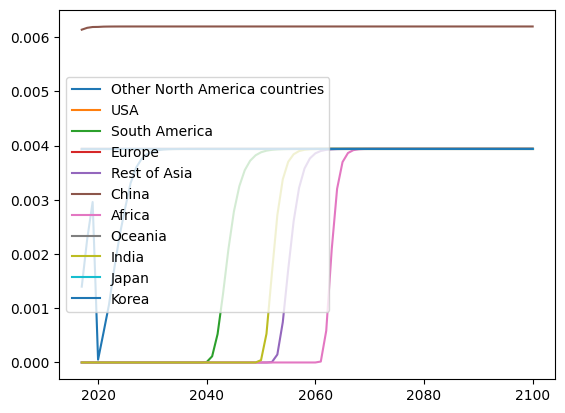

In [11]:

copper.projection_per_region.plot()

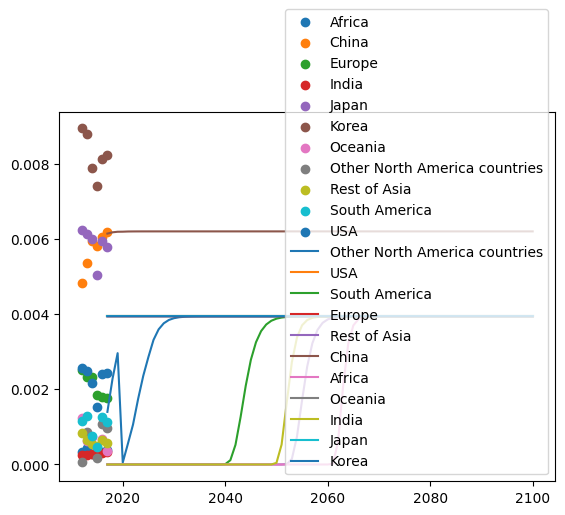

In [12]:
historic_fr_per_cap = copper.historic_other_fraction_consumption/copper.pop.loc[2012:]

fig, ax = plt.subplots()             # Create a figure containing a single Axes.

for region in copper.historic_other_fraction_consumption.columns:
    ax.scatter(list(copper.historic_other_fraction_consumption.index), historic_fr_per_cap[region], label = region)  # Plot some data on the Axes.

ax.plot(copper.projection_per_region, label = copper.projection_per_region.columns)

ax.legend(loc = 'lower right')



plt.show()

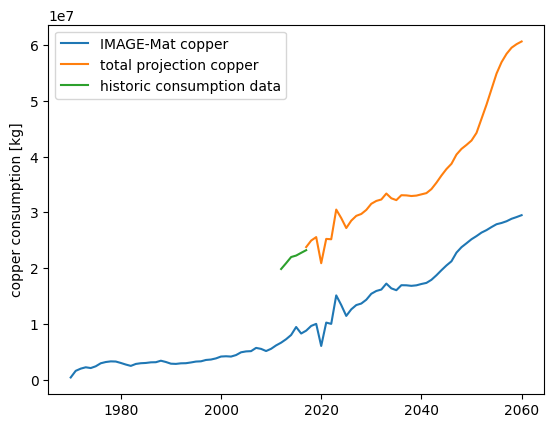

In [13]:
# Plot total copper consumption (all regions)
fig, ax = plt.subplots()             # Create a figure containing a single Axes.


ax.plot(copper.image_mat_data.sum(axis = 1).loc[1970:], label = "IMAGE-Mat copper")
ax.plot((copper.projection_per_region*copper.pop_100.loc[2017:]).sum(axis = 1) + copper.image_mat_data.sum(axis = 1),
        label = "total projection copper")
ax.plot(copper.historic_consumption_data.sum(axis = 1), label = "historic consumption data")

ax.set_ylabel("copper consumption [kg]")

ax.legend(loc = 'upper left')

plt.show()

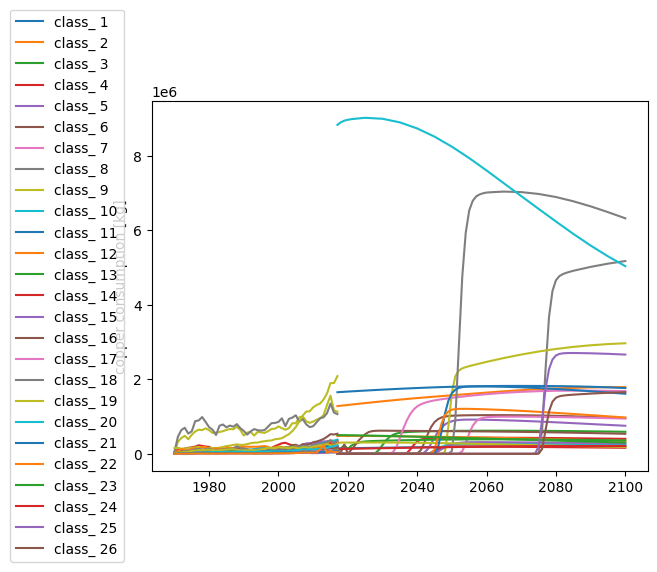

In [14]:
# Total projections per region

fig, ax = plt.subplots()             # Create a figure containing a single Axes.

# project per IMAGE region
copper.project_on_total_IMAGE_regions(REGION_TO_CLASS_DICT, COPPER_AVERAGE_REGIONS_TO_IMAGE)

ax.plot(copper.projection_per_region_IMAGE*copper.pop_100_original.loc[2017:], label = copper.projection_per_region_IMAGE.columns)

ax.plot(copper.image_mat_data.loc[1970:2017])

ax.set_ylabel("copper consumption [kg]")

ax.legend(loc = 'center left', bbox_to_anchor=(-0.3, 0.5))

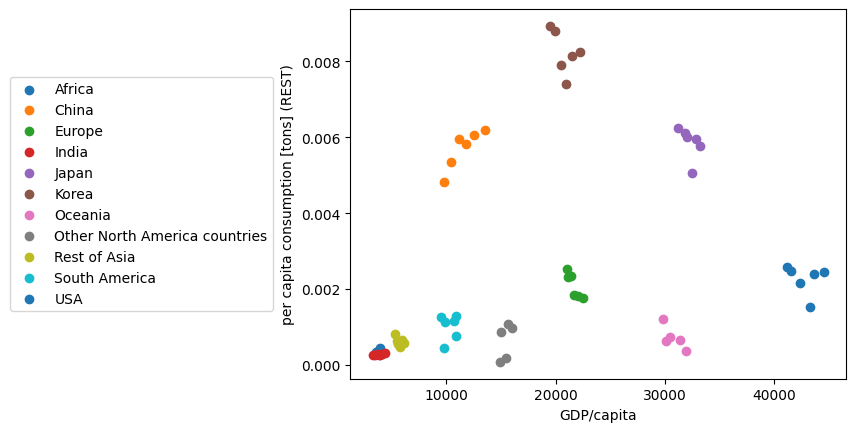

In [15]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted



fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in copper.cons_capita.columns:
    ax.scatter(copper.gdp_pc[region], 
               copper.cons_capita[region], label = region)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

ax.legend(loc = 'center left', bbox_to_anchor=(-0.7, 0.5))


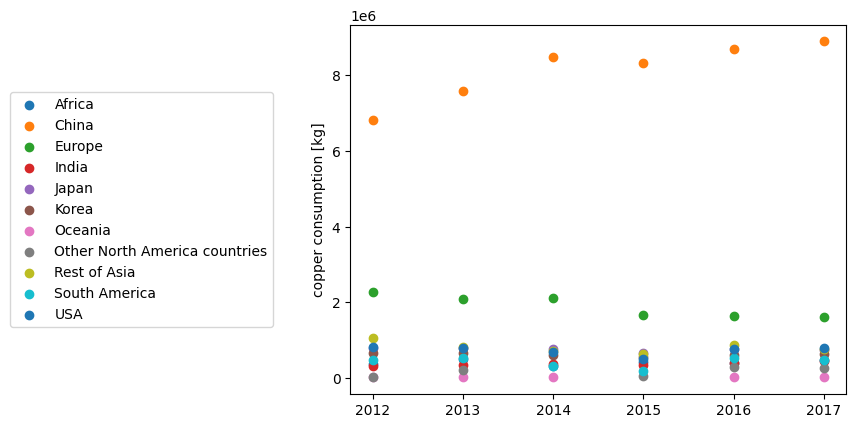

In [16]:
# consumption other fraction per region


fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in copper.historic_other_fraction_consumption.columns:
    ax.scatter(copper.historic_other_fraction_consumption.index, 
               copper.historic_other_fraction_consumption[region], label = region)

ax.set_ylabel("copper consumption [kg]")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.7, 0.5))